In [1]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
sns.set_palette("pastel")

MSE, MAE, Huber


| Feature | Mean Squared Error (MSE / L2) | Mean Absolute Error (MAE / L1) | Huber Loss |
|---|---|---|---|
| Behavior on small errors | Quadratic (precise) | Linear (constant gradient) | Quadratic (precise) |
| Behavior on large errors | Quadratic (explodes for outliers) | Linear (robust) | Linear (robust) |
| Differentiability | Smooth everywhere | Not differentiable at 0 | Smooth everywhere |

Huber:
$$
L_\delta(e)=
\begin{cases}
\frac{1}{2}e^2, & \text{if } |e|\le \delta \\
\delta\left(|e|-\frac{1}{2}\delta\right), & \text{if } |e|>\delta
\end{cases}
$$


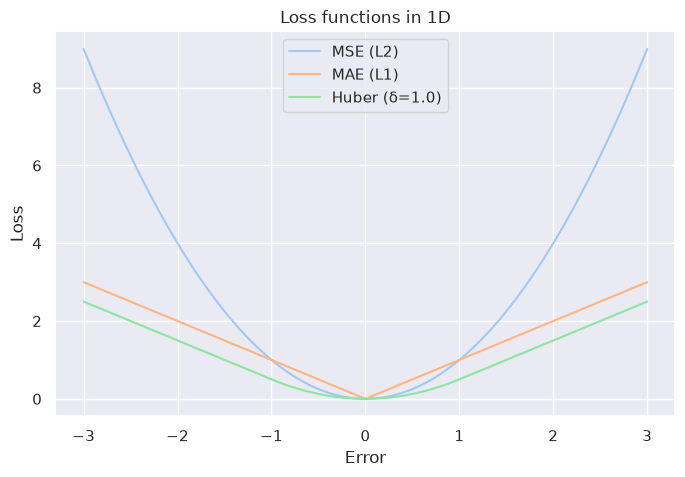

In [2]:
e = jnp.linspace(-3, 3, 400)

mse = e**2
mae = jnp.abs(e)
delta = 1.0
huber = jnp.where(jnp.abs(e) <= delta, 0.5 * e**2, delta * (jnp.abs(e) - 0.5 * delta))

plt.figure(figsize=(8, 5))
plt.plot(e, mse, label="MSE (L2)")
plt.plot(e, mae, label="MAE (L1)")
plt.plot(e, huber, label=f"Huber (δ={delta})")

plt.title("Loss functions in 1D")
plt.xlabel("Error")
plt.ylabel("Loss")
plt.legend()
plt.show()

### classification

### classification

| Feature | Binary Cross-Entropy (BCE) | Categorical Cross-Entropy (CCE) | Hinge Loss |
|---|---|---|---|
| Primary Use Case | Binary classification (2 classes) | Multi-class classification (> 2 classes) | Maximum-margin classification |
| Common Algorithms | Logistic regression, neural networks | Multi-class neural networks | Support Vector Machines (SVM) |
| Output Layer | Sigmoid (outputs 1 probability) | Softmax (outputs a probability vector) | Linear / raw scores |
| Target Labels | \(0\) or \(1\) | One-hot encoded vectors (e.g., \([0, 1, 0]\)) | \(-1\) or \(+1\) |
| Mathematical Goal | Maximize likelihood of the correct class | Maximize likelihood of the correct class | Maximize the geometric margin |
| Sparsity | No (always updates if probability \(\ne 1\)) | No (always updates if probability \(\ne 1\)) | Yes (zero loss if margin \(\ge 1\)) |

Goes to shannon's entropy --  reduce "suprise"

$$
\textbf{Binary Cross-Entropy (BCE)}:\quad
L(y,\hat{y}) = -\left[y\log(\hat{y}) + (1-y)\log(1-\hat{y})\right]
$$

$$
\textbf{Categorical Cross-Entropy (CCE)}:\quad
L(\mathbf{y},\hat{\mathbf{y}}) = -\sum_{k=1}^{K} y_k \log(\hat{y}_k)
$$

$$
\textbf{Hinge Loss}:\quad
L(y,f(x)) = \max(0,\, 1 - y\,f(x))
$$

For multi-class classification, the hinge loss is often written as:

$$
L(\mathbf{y},\mathbf{s}) = \sum_{j \ne y} \max(0,\, s_j - s_y + 1)
$$

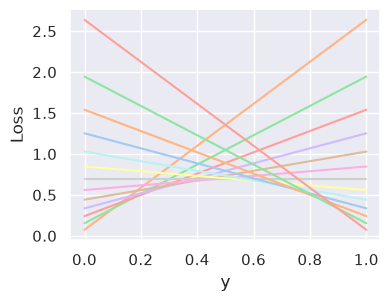

In [6]:
y = jnp.linspace(0.0, 1.0, 400)

plt.figure(figsize=(4, 3))

for y_hat in jnp.linspace(0.0, 1.0, 15):
	bce = -(y * jnp.log(y_hat) + (1 - y) * jnp.log(1 - y_hat))
	plt.plot(y, bce)

plt.xlabel("y")
plt.ylabel("Loss")
plt.show()

#### regularization
aka, lets penalize exploding weights

r1 ridge = mse + λ \sum|w1|

r2 lasso = mse + λ sum(w²)

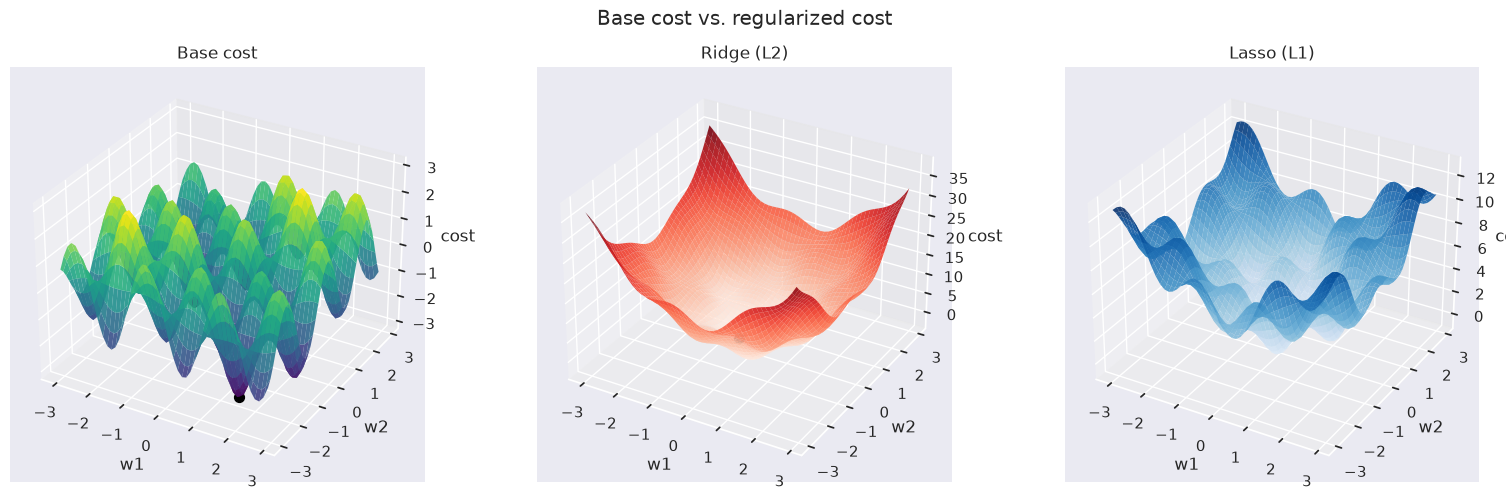

In [19]:
# Add higher-frequency oscillations to base cost
w1_2d, w2_2d = jnp.meshgrid(w1, w2, indexing="ij")

# Base cost: sin(x) sin(y)
base_cost = jnp.sin(w1_2d) * jnp.sin(w2_2d)

# Add oscillatory components for "wiggliness"
frequency = 3.0
amplitude = 2.0
oscillation = amplitude * jnp.sin(frequency * w1_2d) * jnp.cos(frequency * w2_2d)

mse_surface = base_cost + oscillation

lam = 2.0
ridge_reg_surface = mse_surface + lam * (w1_2d**2 + w2_2d**2)
lasso_reg_surface = mse_surface + lam * (jnp.abs(w1_2d) + jnp.abs(w2_2d))

# Find minima
mse_min_idx = tuple(jnp.unravel_index(jnp.argmin(mse_surface), mse_surface.shape))
ridge_min_idx = tuple(jnp.unravel_index(jnp.argmin(ridge_reg_surface), ridge_reg_surface.shape))

step = 8

fig = plt.figure(figsize=(16, 5))
axes = [
	fig.add_subplot(131, projection="3d"),
	fig.add_subplot(132, projection="3d"),
	fig.add_subplot(133, projection="3d"),
]

surfaces = [
	(mse_surface, "Base cost", "viridis", mse_min_idx),
	(ridge_reg_surface, "Ridge (L2)", "Reds", ridge_min_idx),
	(lasso_reg_surface, "Lasso (L1)", "Blues", None),
]

for ax, (surface, title, cmap, min_idx) in zip(axes, surfaces):
	ax.plot_surface(
		w1_2d[::step, ::step],
		w2_2d[::step, ::step],
		surface[::step, ::step],
		cmap=cmap,
		alpha=0.9,
		linewidth=0,
		antialiased=True,
	)

	if min_idx is not None:
		i, j = min_idx
		ax.scatter(
			float(w1_2d[i, j]),
			float(w2_2d[i, j]),
			float(surface[i, j]),
			color="black",
			s=50,
			marker="o",
		)

	ax.set_title(title)
	ax.set_xlabel("w1")
	ax.set_ylabel("w2")
	ax.set_zlabel("cost")

plt.suptitle("Base cost vs. regularized cost")
plt.tight_layout()
plt.show()